1. load data with your data set on the folder 

In [2]:
import pandas as pd
import numpy as np
df = pd.read_excel('data/trade price.xlsx')
df.head()

,Date,Open,High,Low,Close*,Adj Close**,Volume
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000


2. data cleaning

In [3]:
df.rename(columns={
    'Close*': 'Close', 
    'Adj Close**': 'Adj Close'
}, inplace=True)


3. change date type and ascending the data by date

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-05-01,24117.29,24117.29,23808.19,24099.05,24099.05,380070000
1,2018-05-02,24097.63,24185.52,23886.30,23924.98,23924.98,385350000
2,2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000
3,2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000
4,2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000


4. check missing value

In [5]:
df.info()
print("-" * 50)
print("missing value per column:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1258 non-null   datetime64[ns]
 1   Open       1258 non-null   float64       
 2   High       1258 non-null   float64       
 3   Low        1258 non-null   float64       
 4   Close      1258 non-null   float64       
 5   Adj Close  1258 non-null   float64       
 6   Volume     1258 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 68.9 KB
--------------------------------------------------
missing value per column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


5. Setup Target Variable & Handle NaNs

In [6]:
df['Target_Next_Day_Close'] = df['Close'].shift(-1)
df.dropna(inplace=True)
df[['Date', 'Close', 'Target_Next_Day_Close']].tail()

,Date,Close,Target_Next_Day_Close
1252,2023-04-21,33808.96,33875.40
1253,2023-04-24,33875.40,33530.83
1254,2023-04-25,33530.83,33301.87
1255,2023-04-26,33301.87,33826.16
1256,2023-04-27,33826.16,34098.16


6. Feature Selection and Train/Test Split

In [7]:
from sklearn.model_selection import train_test_split

# Select the input features (X) and target (y)
features = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[features]
y = df['Target_Next_Day_Close']

# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")


Training data size: (1005, 5)
Testing data size: (252, 5)


7. Model Initialization and Training

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Coefficients: {model.coef_}")

Coefficients: [-1.45422738e-01  3.40838980e-01  2.85595381e-01  5.15027831e-01
 -1.46696975e-07]


8. Model Evaluation

In [9]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
# Use the trained model to make predictions on the test set
predictions = model.predict(X_test)
# Calculate Evaluation Metrics
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-Squared (R2 Score): {r2:.4f}")

Mean Squared Error (MSE): 146788.10
Root Mean Squared Error (RMSE): 383.13
R-Squared (R2 Score): 0.9182


9. Visualize the Predictions

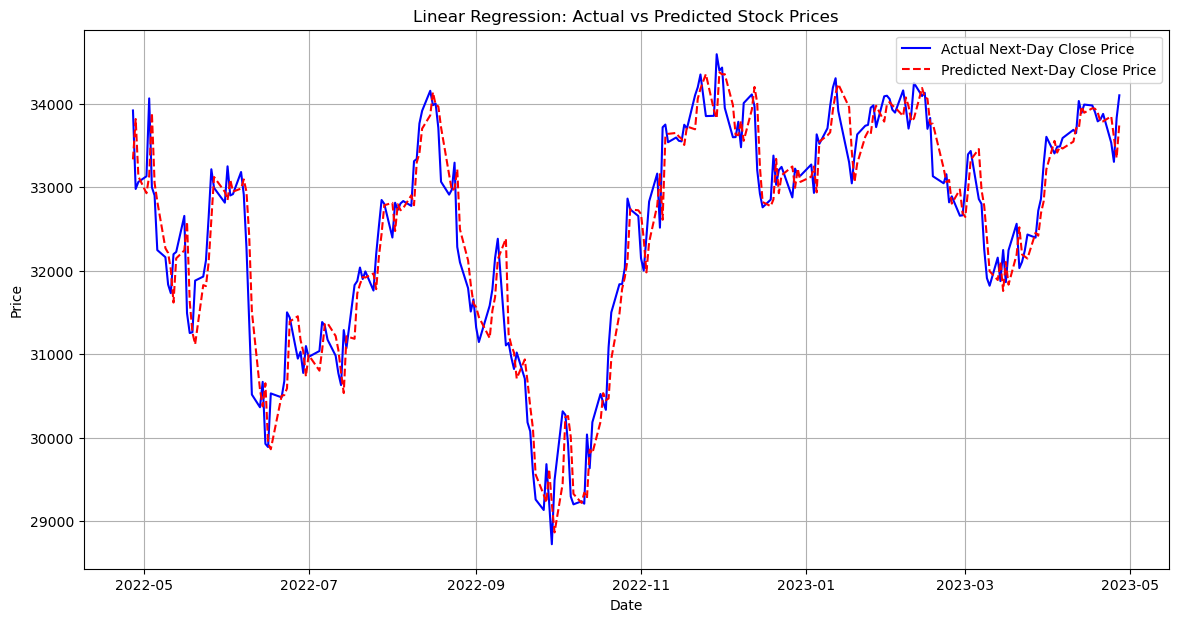

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Get the corresponding dates for our test set
test_dates = df['Date'].iloc[y_test.index]

# Plot the real prices vs the model's predicted prices
plt.plot(test_dates, y_test, label='Actual Next-Day Close Price', color='blue')
plt.plot(test_dates, predictions, label='Predicted Next-Day Close Price', color='red', linestyle='--')

# Adding labels and titles
plt.title('Linear Regression: Actual vs Predicted Stock Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


### Explanation of the Multiple Linear Regression Model

The model used above is **Multiple Linear Regression**, not Simple Linear Regression. The reason is that the model uses **more than one independent variable (feature)** to predict the target (`Target_Next_Day_Close`). In the phase 6 code, we can see that there are 5 features used: `['Open', 'High', 'Low', 'Close', 'Volume']`.

#### 1. Mathematical Formula for Multiple Linear Regression
For Multiple Linear Regression with 5 features, the equation is:
$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_4 X_4 + \beta_5 X_5$$

**Description:**
*   **$Y$**: Target variable (`Target_Next_Day_Close`).
*   **$X_1$ to $X_5$**: Values of the feature variables in order (`Open`, `High`, `Low`, `Close`, `Volume`).
*   **$\beta_0$**: Intercept.
*   **$\beta_1$ to $\beta_5$**: Coefficient weights of each feature concerning the target value $Y$.

#### 2. Interpretation of Output Results
**A. Coefficient Weights Output (Phase 7):**
`[-0.1454,  0.3408,  0.2856,  0.5150, -0.000000146]`
*   **Close ($\beta_4 = 0.5150$)**: The variable with the most positive influence. If today's `Close` price goes up by 1 point, tomorrow's price is predicted to increase by 0.5150.
*   **High ($\beta_2 = 0.3408$) & Low ($\beta_3 = 0.2856$)**: Have a positive effect (price increase) if their values are higher.
*   **Open ($\beta_1 = -0.1454$)**: Has a negative effect, meaning it suppresses tomorrow's price prediction.
*   **Volume ($\beta_5 \approx -0.000000146$)**: Extremely close to 0, meaning it has almost no linear impact on tomorrow's price movement in this model.

**B. Model Evaluation Output (Phase 8):**
*   **MSE (146788.10)**: The average squared difference between the predicted values and the actual values.
*   **RMSE (383.13)**: The average margin of error between the estimated price for tomorrow and the actual price is about 383 points.
*   **R2 Score (0.9182)**: Indicates that the model is highly accurate. The five independent variables can explain about 91.82% of tomorrow's price movements, leaving only about 8.18% of the variance unexplained by the model.
